## **Import Library**

In [2]:
# Data Manipulation & Dasar
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore') # Menyembunyikan peringatan yang tidak perlu

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipeline (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

# Algoritma (Models)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

# Evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deployment & System Operations
import joblib
import os
from google.colab import files

## **Data Understanding**

In [3]:
# Load data
df = pd.read_csv("megaGymDataset.csv", sep=';')
df.head()

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


In [4]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2918 non-null   int64  
 1   Title       2918 non-null   object 
 2   Desc        2918 non-null   object 
 3   Type        2918 non-null   object 
 4   BodyPart    2918 non-null   object 
 5   Equipment   2886 non-null   object 
 6   Level       2918 non-null   object 
 7   Rating      1031 non-null   float64
 8   RatingDesc  862 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 205.3+ KB


In [5]:
# Memeriksa duplikat dan missing values
print('\n--- Data Duplikat---')
print(df.duplicated().sum())
print('\n--- Missing Values ---')
print(df.isnull().sum())


--- Data Duplikat---
0

--- Missing Values ---
Unnamed: 0       0
Title            0
Desc             0
Type             0
BodyPart         0
Equipment       32
Level            0
Rating        1887
RatingDesc    2056
dtype: int64


In [6]:
# Memeriksa distribusi nilai pada kolom kategorikal utama
for col in ['Type', 'BodyPart', 'Equipment', 'Level']:
    print(f'\nDistribusi Semua Data Kolom [{col}]:')
    print(df[col].value_counts())


Distribusi Semua Data Kolom [Type]:
Type
Strength                 2545
Stretching                147
Plyometrics                97
Powerlifting               37
Cardio                     35
Olympic Weightlifting      35
Strongman                  22
Name: count, dtype: int64

Distribusi Semua Data Kolom [BodyPart]:
BodyPart
Abdominals     662
Quadriceps     646
Shoulders      340
Chest          262
Biceps         168
Triceps        151
Lats           124
Hamstrings     121
Middle Back    118
Lower Back      97
Glutes          81
Calves          47
Forearms        31
Traps           24
Abductors       21
Adductors       17
Neck             8
Name: count, dtype: int64

Distribusi Semua Data Kolom [Equipment]:
Equipment
Body Only        1078
Dumbbell          516
Barbell           282
Other             254
Cable             226
Machine           175
Kettlebells       149
Bands             100
Medicine Ball      38
Exercise Ball      35
E-Z Curl Bar       22
Foam Roll          11
Name: c

### **Data Preparation**

In [7]:
# Pembersihan, Rekayasa Fitur, & Balancing
# hapus 'Unnamed: 0', 'Rating', dan 'RatingDesc'
kolom_di_drop = ['Unnamed: 0', 'Rating', 'RatingDesc']
df = df.drop(columns=kolom_di_drop, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      2918 non-null   object
 1   Desc       2918 non-null   object
 2   Type       2918 non-null   object
 3   BodyPart   2918 non-null   object
 4   Equipment  2886 non-null   object
 5   Level      2918 non-null   object
dtypes: object(6)
memory usage: 136.9+ KB


In [8]:
# Pembersihan data (Drop duplikat & missing values pada kolom krusial)
df = df.copy()
df = df.drop_duplicates(subset=['Title'])
df = df.dropna(subset=['Title', 'Desc', 'Type', 'BodyPart', 'Equipment', 'Level'])

In [9]:
# Rekayasa Fitur (Feature Engineering): Menggabungkan Title dan Desc menjadi satu kolom teks
df['text'] = df['Title'].astype(str) + ' ' + df['Desc'].astype(str)
print('Shape Setelah Pembersihan:', df.shape)

Shape Setelah Pembersihan: (2877, 7)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2877 entries, 0 to 2917
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      2877 non-null   object
 1   Desc       2877 non-null   object
 2   Type       2877 non-null   object
 3   BodyPart   2877 non-null   object
 4   Equipment  2877 non-null   object
 5   Level      2877 non-null   object
 6   text       2877 non-null   object
dtypes: object(7)
memory usage: 179.8+ KB


In [11]:
# Penanganan Ketidakseimbangan Kelas (Undersampling kelas mayoritas)
max_per_class = 200
balanced_parts = []

for bodypart, group in df.groupby('BodyPart'):
    if len(group) > max_per_class:
        group = resample(group, replace=False, n_samples=max_per_class, random_state=42)
    balanced_parts.append(group)

df_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)
print('\nShape Setelah Di-balancing:', df_balanced.shape)
print(df_balanced['BodyPart'].value_counts())


Shape Setelah Di-balancing: (1786, 7)
BodyPart
Chest          200
Quadriceps     200
Shoulders      200
Abdominals     200
Biceps         168
Triceps        151
Lats           121
Middle Back    116
Hamstrings     115
Lower Back      93
Glutes          81
Calves          44
Forearms        30
Traps           23
Abductors       21
Adductors       15
Neck             8
Name: count, dtype: int64


In [12]:
# Splitting Data (Membagi data training dan testing secara stratify)
X = df_balanced[['text', 'Type', 'Equipment', 'Level']]
y = df_balanced['BodyPart']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('\nDimensi Data Train:', X_train.shape)
print('Dimensi Data Test :', X_test.shape)


Dimensi Data Train: (1428, 4)
Dimensi Data Test : (358, 4)


In [13]:
# Pemetaan tujuan latihan (Goal) ke tipe latihan, set, dan repetisi
goal_map = {
    "Muscle Gain": {
        "preferred_types": ["Strength", "Powerlifting", "Strongman"],
        "sets": "3-4 set",
        "reps": "8-12 repetisi",
    },
    "Fat Loss": {
        "preferred_types": ["Strength", "Cardio", "Plyometrics"],
        "sets": "3 set",
        "reps": "12-15 repetisi",
    },
    "Strength": {
        "preferred_types": ["Strength", "Powerlifting", "Olympic Weightlifting"],
        "sets": "4-5 set",
        "reps": "4-8 repetisi",
    },
}

# Template pembagian latihan (Split) berdasarkan jumlah hari per minggu
split_templates = {
    2: ['Upper Body', 'Lower Body'],
    3: ['Push', 'Pull', 'Legs'],
    4: ['Chest/Shoulders/Triceps', 'Back/Biceps', 'Legs/Core', 'Full Body'],
    5: ['Chest', 'Back', 'Legs', 'Shoulders/Arms', 'Core/Conditioning']
}

# Batasan tingkat kemahiran (Level) yang diizinkan untuk keamanan user
allowed_level_map = {
    'Beginner': ['Beginner'],
    'Intermediate': ['Beginner', 'Intermediate'],
    'Expert': ['Intermediate', 'Expert']
}

# Prioritas target otot (BodyPart) untuk setiap fokus harian
bodypart_priority_map = {
    'Upper Body': ['Chest', 'Shoulders', 'Triceps', 'Biceps', 'Lats', 'Middle Back'],
    'Lower Body': ['Quadriceps', 'Hamstrings', 'Glutes', 'Calves'],
    'Push': ['Chest', 'Shoulders', 'Triceps'],
    'Pull': ['Lats', 'Middle Back', 'Biceps', 'Lower Back', 'Traps'],
    'Legs': ['Quadriceps', 'Hamstrings', 'Glutes', 'Calves'],
    'Chest/Shoulders/Triceps': ['Chest', 'Shoulders', 'Triceps'],
    'Back/Biceps': ['Lats', 'Middle Back', 'Biceps', 'Lower Back', 'Traps'],
    'Legs/Core': ['Quadriceps', 'Hamstrings', 'Glutes', 'Calves', 'Abdominals'],
    'Full Body': ['Chest', 'Lats', 'Shoulders', 'Quadriceps', 'Hamstrings', 'Glutes', 'Abdominals'],
    'Chest': ['Chest'],
    'Back': ['Lats', 'Middle Back', 'Lower Back', 'Traps'],
    'Shoulders/Arms': ['Shoulders', 'Biceps', 'Triceps', 'Forearms'],
    'Core/Conditioning': ['Abdominals']
}

# Aturan Bisnis Baru: Pemetaan tempat latihan ke alat yang tersedia
location_equipment_map = {
    'gym': ['All'],
    'rumah_ada_alat': ['Dumbbell', 'Bands', 'Body Only','Exercise Ball', 'Mat'],
    'rumah_tanpa_alat': ['Body Only']
}

In [14]:
kategori_df = df_balanced[['Type', 'Equipment', 'Level']]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_result = ohe.fit_transform(kategori_df)

nama_kolom_baru = ohe.get_feature_names_out(['Type', 'Equipment', 'Level'])
df_ohe_visual = pd.DataFrame(ohe_result, columns=nama_kolom_baru)

print("Dimensi hasil One Hot Encoding:", df_ohe_visual.shape)
display(df_ohe_visual.head())

Dimensi hasil One Hot Encoding: (1786, 22)


,Type_Cardio,Type_Olympic Weightlifting,Type_Plyometrics,Type_Powerlifting,Type_Strength,Type_Stretching,Type_Strongman,Equipment_Bands,Equipment_Barbell,Equipment_Body Only,...,Equipment_E-Z Curl Bar,Equipment_Exercise Ball,Equipment_Foam Roll,Equipment_Kettlebells,Equipment_Machine,Equipment_Medicine Ball,Equipment_Other,Level_Beginner,Level_Expert,Level_Intermediate
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### **Modeling**

In [15]:
# MODELING (Melatih Klasifikasi Multimodel untuk Perbandingan)

# Definisi Preprocessor (Berlaku sama untuk semua model)
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=2000, ngram_range=(1, 2), stop_words='english'), 'text'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Type', 'Equipment', 'Level'])
    ]
)

# Inisialisasi 3 Kandidat Model ke dalam Dictionary Pipeline
models_pool = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
    ]),

    'Naive Bayes': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', MultinomialNB())
    ])
}

# Proses Training Semua Model secara Paralel
trained_models = {}
for model_name, pipeline in models_pool.items():
    print(f"Melatih Model: {model_name}...")
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline
    print(f"{model_name} berhasil dilatih.\n")

Melatih Model: Logistic Regression...
Logistic Regression berhasil dilatih.

Melatih Model: Random Forest...
Random Forest berhasil dilatih.

Melatih Model: Naive Bayes...
Naive Bayes berhasil dilatih.



### **Evaluation**

In [22]:
# Komparasi Akurasi & Pemilihan Model Terbaik
scores_summary = []
best_acc = 0
best_model_name = ""
model = None # Ini variabel penampung model terbaik yang akan dipakai fungsi rekomendasi

print("=" * 80)
print("                    TABEL KOMPARASI PERFORMA MODEL                            ")
print("=" * 80)

# Evaluate tiap model yang sudah dilatih
for model_name, trained_pipeline in trained_models.items():
    y_pred = trained_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Simpan skor ke list untuk tabel ringkasan
    scores_summary.append({
        'Model Name': model_name,
        'Accuracy Score': round(acc, 4)
    })

    # Logika mencari model dengan akurasi tertinggi otomatis
    if acc > best_acc:
        best_acc = acc
        best_model_name = model_name
        model = trained_pipeline # Mengunci model terbaik ke variabel global 'model'

# Tampilkan Tabel Perbandingan ringkas
df_comparison = pd.DataFrame(scores_summary).sort_values(by='Accuracy Score', ascending=False).reset_index(drop=True)
display(df_comparison)

print("-" * 80)
print(f"MODEL TERBAIK YANG DIPILIH SISTEM: {best_model_name} (Accuracy: {round(best_acc, 4)})")
print("=" * 80)

# Menampilkan rincian performa mendalam khusus untuk Model Terbaik pilihan sistem
print(f"\nRincian Laporan Klasifikasi Lengkap untuk {best_model_name}:")
y_best_pred = model.predict(X_test)
print(classification_report(y_test, y_best_pred, zero_division=0))

                    TABEL KOMPARASI PERFORMA MODEL                            


,Model Name,Accuracy Score
0,Random Forest,0.7179
1,Logistic Regression,0.6816
2,Naive Bayes,0.5698


--------------------------------------------------------------------------------
MODEL TERBAIK YANG DIPILIH SISTEM: Random Forest (Accuracy: 0.7179)

Rincian Laporan Klasifikasi Lengkap untuk Random Forest:
              precision    recall  f1-score   support

  Abdominals       0.72      0.78      0.75        40
   Abductors       0.33      0.25      0.29         4
   Adductors       0.00      0.00      0.00         3
      Biceps       0.87      0.97      0.92        34
      Calves       0.90      1.00      0.95         9
       Chest       0.72      0.95      0.82        40
    Forearms       1.00      0.33      0.50         6
      Glutes       0.67      0.62      0.65        16
  Hamstrings       0.58      0.48      0.52        23
        Lats       0.67      0.42      0.51        24
  Lower Back       0.68      0.68      0.68        19
 Middle Back       0.64      0.61      0.62        23
        Neck       1.00      0.50      0.67         2
  Quadriceps       0.56      0.62   

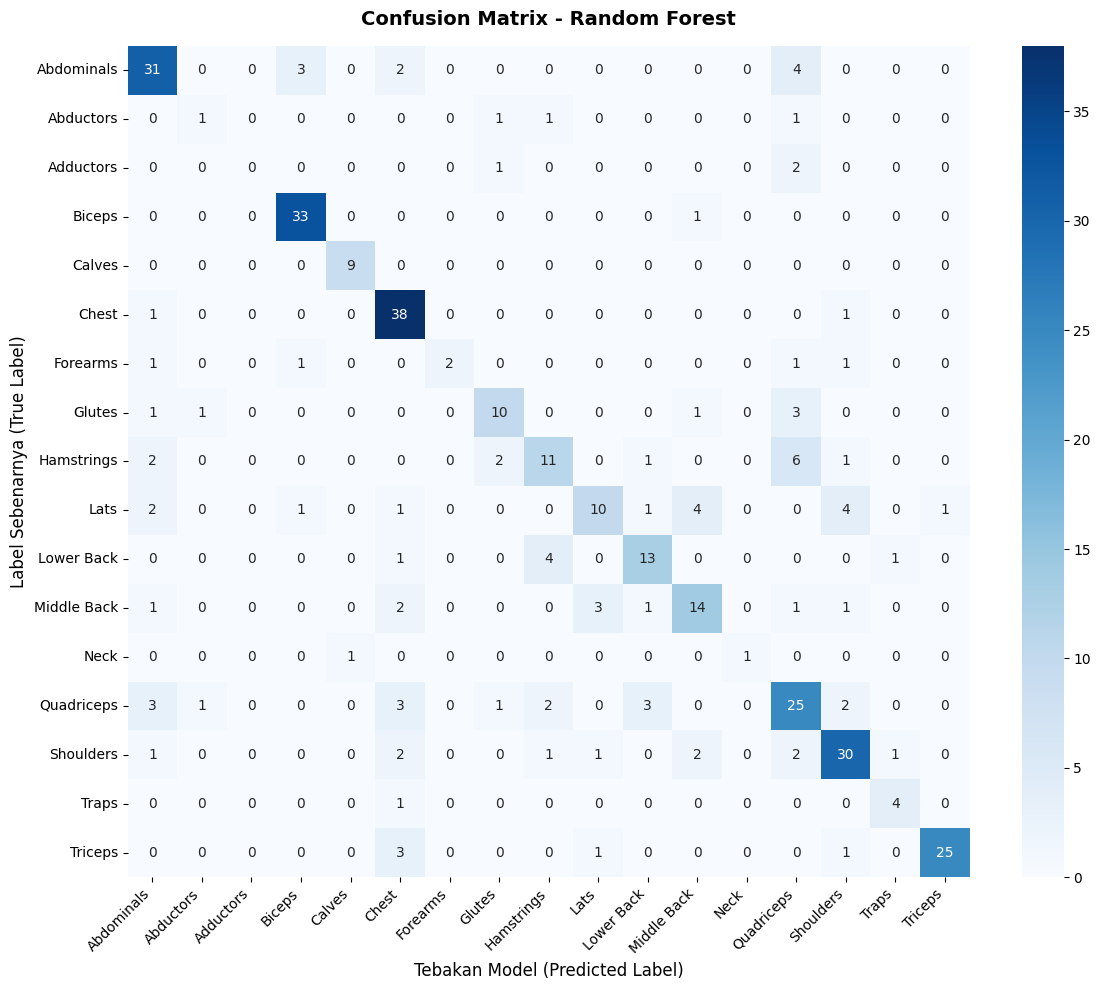

In [23]:
# Confusion Matrix

# Menghitung nilai confusion matrix
cm = confusion_matrix(y_test, y_best_pred)

# Membuat visualisasi heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Label Sebenarnya (True Label)', fontsize=12)
plt.xlabel('Tebakan Model (Predicted Label)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Memiringkan teks agar tidak bertumpuk
plt.tight_layout()
plt.show()

### **Test Program**

In [24]:
# DEPLOYMENT (Fungsi Utama - Gym Otomatis Semua Alat)

def recommend_workout(
    user_level='Beginner',
    user_location='gym',          # Pilihan: 'gym' atau 'rumah'
    has_equipment=True,           # Hanya berlaku jika user_location='rumah' (True/False)
    user_goal='Muscle Gain',
    custom_schedule=None,
    exercises_per_day=6,
    random_state=None
):
    # Logika seed yang aman untuk None
    if random_state is not None:
        np.random.seed(random_state)

    data = df.copy()

    if custom_schedule is None:
        custom_schedule = {
            'Hari Ke-1': ['Chest', 'Biceps', 'Triceps'],
            'Hari Ke-2': ['Lats', 'Middle Back', 'Biceps']
        }

    # Constraint Filtering berdasarkan Level
    allowed_levels = allowed_level_map.get(user_level, [user_level])
    data = data[data['Level'].isin(allowed_levels)].copy()

    # Constraint Filtering berdasarkan Tempat & Ketersediaan Alat
    if user_location == 'gym':
        # JIKA DI GYM: Tidak memfilter alat sama sekali (Bebas menggunakan seluruh isi dataset)
        equipment_candidates = data['Equipment'].unique().tolist()
    elif user_location == 'rumah':
        if has_equipment:
            equipment_candidates = location_equipment_map['rumah_ada_alat']
        else:
            equipment_candidates = location_equipment_map['rumah_tanpa_alat']

    # Terapkan hasil filter alat ke dataset
    data = data[data['Equipment'].isin(equipment_candidates)].copy()

    # Constraint Filtering berdasarkan Goal
    preferred_types = goal_map[user_goal]['preferred_types']
    data = data[data['Type'].isin(preferred_types)].copy()

    if len(data) == 0:
        return {'error': 'Tidak ada data gerakan yang cocok dengan batasan spesifik tempat dan goal Anda.'}

    # Prediksi Probabilitas Machine Learning
    pred_input = data[['text', 'Type', 'Equipment', 'Level']]
    proba = model.predict_proba(pred_input)
    classes = model.classes_
    proba_df = pd.DataFrame(proba, columns=classes, index=data.index)
    data = pd.concat([data, proba_df], axis=1)

    # Penyusunan Jadwal Rekomendasi (Kuota Adil per Otot)
    used_titles = set()
    schedule = []

    for day_name, target_parts in custom_schedule.items():
        num_muscles = len(target_parts)
        base_exercises_per_muscle = exercises_per_day // num_muscles
        remainder = exercises_per_day % num_muscles

        day_chunks = []

        for i, muscle in enumerate(target_parts):
            quota = base_exercises_per_muscle + (1 if i < remainder else 0)
            if quota == 0:
                continue

            # HARD FILTER: hanya ambil gerakan yang BodyPart-nya Sesuai
            temp = data[data['BodyPart'] == muscle].copy()
            temp = temp[~temp['Title'].isin(used_titles)]

            if len(temp) == 0:
                continue

            if muscle in temp.columns:
                temp['score_ml'] = temp[[muscle]].iloc[:, 0]
            else:
                temp['score_ml'] = 0.0

            # Definisikan fungsi pembobotan dinamis di dalam loop atau fungsi utama
            def get_rule_score(row):
                score = 0.5 # Skor dasar (Base score)

                # 1.LEVEL: Utamakan gerakan yang levelnya pas/sama persis dengan user
                if row['Level'] == user_level:
                    score += 0.2

                # 2.ALAT BERDASARKAN LOKASI
                if user_location == 'gym':
                    # Di gym, utamakan alat berat (efektif untuk hipertrofi/kekuatan)
                    if row['Equipment'] in ['Barbell', 'Dumbbell', 'Machine', 'Cable']:
                        score += 0.2
                elif user_location == 'rumah':
                    # Di rumah, gerakan yang tidak butuh alat rumit diberi nilai lebih tinggi
                    if row['Equipment'] in ['Body Only', 'Bands']:
                        score += 0.15

                # 3.GOAL
                if user_goal == 'Muscle Gain' and row['Type'] == 'Strength':
                    score += 0.15
                elif user_goal == 'Fat Loss' and row['Type'] in ['Cardio', 'Plyometrics']:
                    score += 0.15

                # Pastikan skor maksimal adalah 1.0 agar seimbang dengan score_ml
                return min(score, 1.0)

            # Terapkan perhitungan aturan dinamis ke setiap baris gerakan
            temp['score_rule'] = temp.apply(get_rule_score, axis=1)

            # Hitung skor akhir
            temp['final_score'] = (0.7 * temp['score_ml']) + (0.3 * temp['score_rule'])
            temp = temp.sort_values(['final_score'], ascending=False)

            # LOGIKA TOP-K RANDOM SAMPLING
            top_k = 10 # Mengambil pool 10 gerakan terbaik
            top_k_pool = temp.head(top_k)

            if len(top_k_pool) > quota:
                # Pilih acak sejumlah 'quota' dari 10 gerakan terbaik
                muscle_chunk = top_k_pool.sample(n=quota, random_state=None).copy()
            else:
                # Jika data yang tersedia <= kuota, ambil semuanya
                muscle_chunk = top_k_pool.copy()

            # Mengurutkan kembali agar skor tertinggi tetap tampil di atas
            muscle_chunk = muscle_chunk.sort_values(['final_score'], ascending=False)

            if len(muscle_chunk) > 0:
                used_titles.update(muscle_chunk['Title'].tolist())
                day_chunks.append(muscle_chunk)

        if day_chunks:
            day_exercises = pd.concat(day_chunks).reset_index(drop=True)
            day_exercises = day_exercises.sort_values(['final_score'], ascending=False).reset_index(drop=True)
        else:
            continue

        schedule.append({
            'day': day_name,
            'focus': ", ".join(target_parts),
            'set_rekomendasi': goal_map[user_goal]['sets'],
            'rep_rekomendasi': goal_map[user_goal]['reps'],
            'exercises': day_exercises[['Title', 'BodyPart', 'Equipment', 'Level', 'Type', 'final_score']].reset_index(drop=True)
        })

    return {
        'user_profile': {
            'level': user_level,
            'location': user_location,
            'has_equipment': has_equipment if user_location == 'rumah' else 'N/A',
            'chosen_equipment': 'All Gym Equipment' if user_location == 'gym' else ('Home Equipment' if has_equipment else 'None (Bodyweight)'),
            'goal': user_goal,
            'days_per_week': len(custom_schedule)
        },
        'schedule': schedule
    }

In [25]:
# TAHAP SIMULASI INTERAKTIF (VERSI SEDERHANA - GYM ALL EQUIPMENT)
user_pilihan_otot = {
    'Hari Ke-1': ['Chest', 'Biceps', 'Triceps'],
    'Hari Ke-2': ['Lats', 'Middle Back', 'Biceps']
}

# Input Profil Baru yang Jauh Lebih Sederhana
input_level = 'Beginner'
input_location = 'gym'           # Pilihan tinggal: 'gym' atau 'rumah'
input_has_equipment = True       # Hanya dibaca jika kamu memilih input_location='rumah'
input_goal = 'Fat Loss'
input_exercises_per_day = 6

# Jalankan fungsi
test_result = recommend_workout(
    user_level=input_level,
    user_location=input_location,
    has_equipment=input_has_equipment,
    user_goal=input_goal,
    custom_schedule=user_pilihan_otot,
    exercises_per_day=input_exercises_per_day
)

# Cetak Tabel Hasil
print("=" * 80)
print("             HASIL PENGUJIAN JADWAL LATIHAN (VERSI SEDERHANA)                 ")
print("=" * 80)

if 'error' in test_result:
    print(f"⚠️ GAGAL: {test_result['error']}")
else:
    prof = test_result['user_profile']
    print(f" [LOKASI] {prof['location'].upper()} | Akses Alat: {prof['chosen_equipment']}")
    print(f" [TARGET] Goal: {prof['goal']} | Frekuensi Total: {prof['days_per_week']} Hari")
    print("-" * 80)

    for day in test_result['schedule']:
        print(f"\n {day['day'].upper()} - TARGET OTOT PILIHAN: {day['focus']}")
        print(f"   Set Rekomendasi: {day['set_rekomendasi']} | Repetisi: {day['rep_rekomendasi']}")

        df_display = day['exercises'].copy()
        df_display['final_score'] = df_display['final_score'].round(4)

        display(df_display)
        print("-" * 60)

             HASIL PENGUJIAN JADWAL LATIHAN (VERSI SEDERHANA)                 
 [LOKASI] GYM | Akses Alat: All Gym Equipment
 [TARGET] Goal: Fat Loss | Frekuensi Total: 2 Hari
--------------------------------------------------------------------------------

 HARI KE-1 - TARGET OTOT PILIHAN: Chest, Biceps, Triceps
   Set Rekomendasi: 3 set | Repetisi: 12-15 repetisi


,Title,BodyPart,Equipment,Level,Type,final_score
0,Cross-body hammer curl,Biceps,Dumbbell,Beginner,Strength,0.949
1,Machine Preacher Curls,Biceps,Machine,Beginner,Strength,0.928
2,Seated Bent-Over One-Arm Dumbbell Triceps Exte...,Triceps,Dumbbell,Beginner,Strength,0.893
3,Incline cable chest press,Chest,Cable,Beginner,Strength,0.865
4,Decline Smith Press,Chest,Machine,Beginner,Strength,0.861
5,Lying Close-Grip Barbell Triceps Press To Chin,Triceps,E-Z Curl Bar,Beginner,Strength,0.854


------------------------------------------------------------

 HARI KE-2 - TARGET OTOT PILIHAN: Lats, Middle Back, Biceps
   Set Rekomendasi: 3 set | Repetisi: 12-15 repetisi


,Title,BodyPart,Equipment,Level,Type,final_score
0,Lying Close-Grip Bar Curl On High Pulley,Biceps,Cable,Beginner,Strength,0.949
1,Cable rope preacher hammer curl,Biceps,Cable,Beginner,Strength,0.928
2,Straight Bar Bench Mid Rows,Middle Back,Barbell,Beginner,Strength,0.837
3,Machine-assisted pull-up,Lats,Machine,Beginner,Strength,0.788
4,Two-Arm Kettlebell Row,Middle Back,Kettlebells,Beginner,Strength,0.735
5,L-sit chin-up,Lats,Other,Beginner,Strength,0.714


------------------------------------------------------------


In [26]:
# Penyimpanan & Unduh Model Fisik + Dataset Bersih
print("Memulai proses ekspor dan penyimpanan komponen sistem...")
print("-" * 60)

# Menyimpan Model Terbaik Hasil Komparasi
# Memastikan model terbaik dari Tahap 5 disimpan ke dalam file format .pkl
nama_file_model = 'model_klasifikasi_bodypart.pkl'
try:
    joblib.dump(model, nama_file_model)
    print(f"Sukses: Model telah disimpan secara lokal di server Colab dengan nama '{nama_file_model}'")
except Exception as e:
    print(f"Gagal menyimpan model. Pastikan cell modeling dan evaluation sudah dijalankan. Error: {e}")

# Menyimpan Dataset yang Sudah Dibersihkan
# Kita simpan dataframe 'df' (atau 'df_balanced' jika ingin versi seimbang) ke dalam file .csv baru
nama_file_csv = 'exercise_clean_final.csv'
try:
    # index=False digunakan agar kolom angka indeks baru tidak ikut terbuat di dalam file CSV
    df.to_csv(nama_file_csv, index=False)
    print(f"Sukses: Dataset bersih telah disimpan secara lokal di server Colab dengan nama '{nama_file_csv}'")
except Exception as e:
    print(f"Gagal menyimpan dataset. Error: {e}")

print("-" * 60)
print("Memicu unduhan otomatis ke komputer lokal Anda...")
print("(Catatan: Mohon klik 'Allow/Izinkan' jika browser Anda memunculkan pop-up izin download)")
print("-" * 60)

# Mengunduh File Langsung ke Folder Downloads Komputer Kamu
# Proses download file model .pkl
if os.path.exists(nama_file_model):
    files.download(nama_file_model)
    print(f"File '{nama_file_model}' sedang diunduh...")

# Proses download file dataset .csv bersih
if os.path.exists(nama_file_csv):
    files.download(nama_file_csv)
    print(f"File '{nama_file_csv}' sedang diunduh...")

print("\n Selesai! Silakan periksa folder 'Downloads' pada komputer atau laptop Anda.")

Memulai proses ekspor dan penyimpanan komponen sistem...
------------------------------------------------------------
Sukses: Model telah disimpan secara lokal di server Colab dengan nama 'model_klasifikasi_bodypart.pkl'
Sukses: Dataset bersih telah disimpan secara lokal di server Colab dengan nama 'exercise_clean_final.csv'
------------------------------------------------------------
Memicu unduhan otomatis ke komputer lokal Anda...
(Catatan: Mohon klik 'Allow/Izinkan' jika browser Anda memunculkan pop-up izin download)
------------------------------------------------------------


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'model_klasifikasi_bodypart.pkl' sedang diunduh...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'exercise_clean_final.csv' sedang diunduh...

 Selesai! Silakan periksa folder 'Downloads' pada komputer atau laptop Anda.
